# 13 — Encounter-Centered Vigor (Count-Based)

Visualize pre/post encounter pressing rates using the corrected encounter time frame.
Key contrasts: threat, attack, distance, and parameter tertile splits.

In [1]:
# ── SETUP ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

ROOT       = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
VIGOR_PROC = ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_processed'
VIGOR_PREP = ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_prep'
STAGE2     = ROOT / 'data' / 'exploratory_350' / 'processed' / 'stage2_trial_processing_20260317_094210'
STATS_DIR  = ROOT / 'results' / 'stats'
FIGS_DIR   = ROOT / 'results' / 'figs'; FIGS_DIR.mkdir(parents=True, exist_ok=True)

DPI = 150
THREAT_COLORS = {0.1: '#2196F3', 0.5: '#FF9800', 0.9: '#F44336'}
THREAT_LABELS = {0.1: 'Low (0.1)', 0.5: 'Med (0.5)', 0.9: 'High (0.9)'}

# ── Load data ──
kp = pd.read_parquet(VIGOR_PREP / 'keypress_events.parquet')
pm = pd.read_parquet(VIGOR_PROC / 'phase_vigor_metrics.parquet')
subj_cap = pd.read_csv(VIGOR_PROC / 'subject_press_capacity.csv', index_col='subj')['capacity_pps']

# Original encounterTime from stage2 (trial-start-relative, NOT effort-onset-relative)
with open(STAGE2 / 'processed_trials.pkl', 'rb') as f:
    pt = pickle.load(f)
pt['subj'] = pt.groupby('participantID').ngroup() + 1
pt['trial'] = pt.groupby('subj').cumcount()
enc_lookup = pt[['subj','trial','encounterTime','firstEffortTime']].copy()
enc_lookup = enc_lookup.rename(columns={'encounterTime': 'enc_abs'})

# Merge onto keypresses
trial_info = pm[['subj','trial','threat','isAttackTrial','outcome','choice',
                  'effort_H','distance_H','trialEndTime']].copy()
kp = kp.merge(trial_info, on=['subj','trial'], how='inner')
kp = kp.merge(enc_lookup[['subj','trial','enc_abs']], on=['subj','trial'], how='inner')

# Load model params
param_df = pd.DataFrame({
    p: pd.read_csv(STATS_DIR / f'FET_Exp_Bias_{p}_params.csv')
       .rename(columns={'subject':'subj'}).set_index('subj')['median']
    for p in ['z','k','beta']
})
param_df.columns = ['z','kappa','beta']

# Compute tertiles
for c in param_df.columns:
    param_df[f'{c}_tert'] = pd.qcut(param_df[c], 3, labels=['Low','Mid','High'])

print(f'Keypresses: {len(kp):,}')
print(f'Subjects: {kp["subj"].nunique()}')
print(f'enc_abs range: [{kp["enc_abs"].min():.1f}, {kp["enc_abs"].max():.1f}]s')

Keypresses: 899,936
Subjects: 293
enc_abs range: [2.5, 5.0]s


In [2]:
# ── BUILD TRIAL-LEVEL ENCOUNTER DATA ──────────────────────────────────────────

# Assign phases using CORRECT (trial-start-relative) encounter time
enc = kp['enc_abs']
kp['phase'] = None
kp.loc[(kp['t'] >= enc - 2) & (kp['t'] < enc), 'phase'] = 'pre'
kp.loc[(kp['t'] >= enc) & (kp['t'] < enc + 2), 'phase'] = 'post'

kp_enc = kp[kp['phase'].notna()].copy()

# Count presses per phase per trial
pc = kp_enc.groupby(['subj','trial','phase']).size().unstack(fill_value=0).reset_index()
pc = pc.merge(trial_info, on=['subj','trial'])
pc = pc.merge(enc_lookup[['subj','trial','enc_abs']], on=['subj','trial'])
pc = pc.merge(subj_cap.to_frame('capacity'), left_on='subj', right_index=True)
pc = pc.merge(param_df, left_on='subj', right_index=True)

# Capacity-normalized rates
pc['pre_rate'] = (pc['pre'] / 2.0) / pc['capacity']
pc['post_rate'] = (pc['post'] / 2.0) / pc['capacity']

# Choice-ratio normalization
for col in ['pre_rate', 'post_rate']:
    ch_mean = pc.groupby('choice')[col].transform('mean')
    pc[f'{col}_adj'] = pc[col] / ch_mean

pc['transition'] = pc['post_rate_adj'] - pc['pre_rate_adj']
pc['attack'] = pc['isAttackTrial'].astype(int)

# Filter to trials with both pre and post
has_both = (pc['pre'] > 0) & (pc['post'] > 0)
pc = pc[has_both].copy()

print(f'Trials with both pre & post: {len(pc):,} ({has_both.mean():.1%} of total)')
print(f'Subjects: {pc["subj"].nunique()}')

Trials with both pre & post: 20,592 (88.8% of total)
Subjects: 293


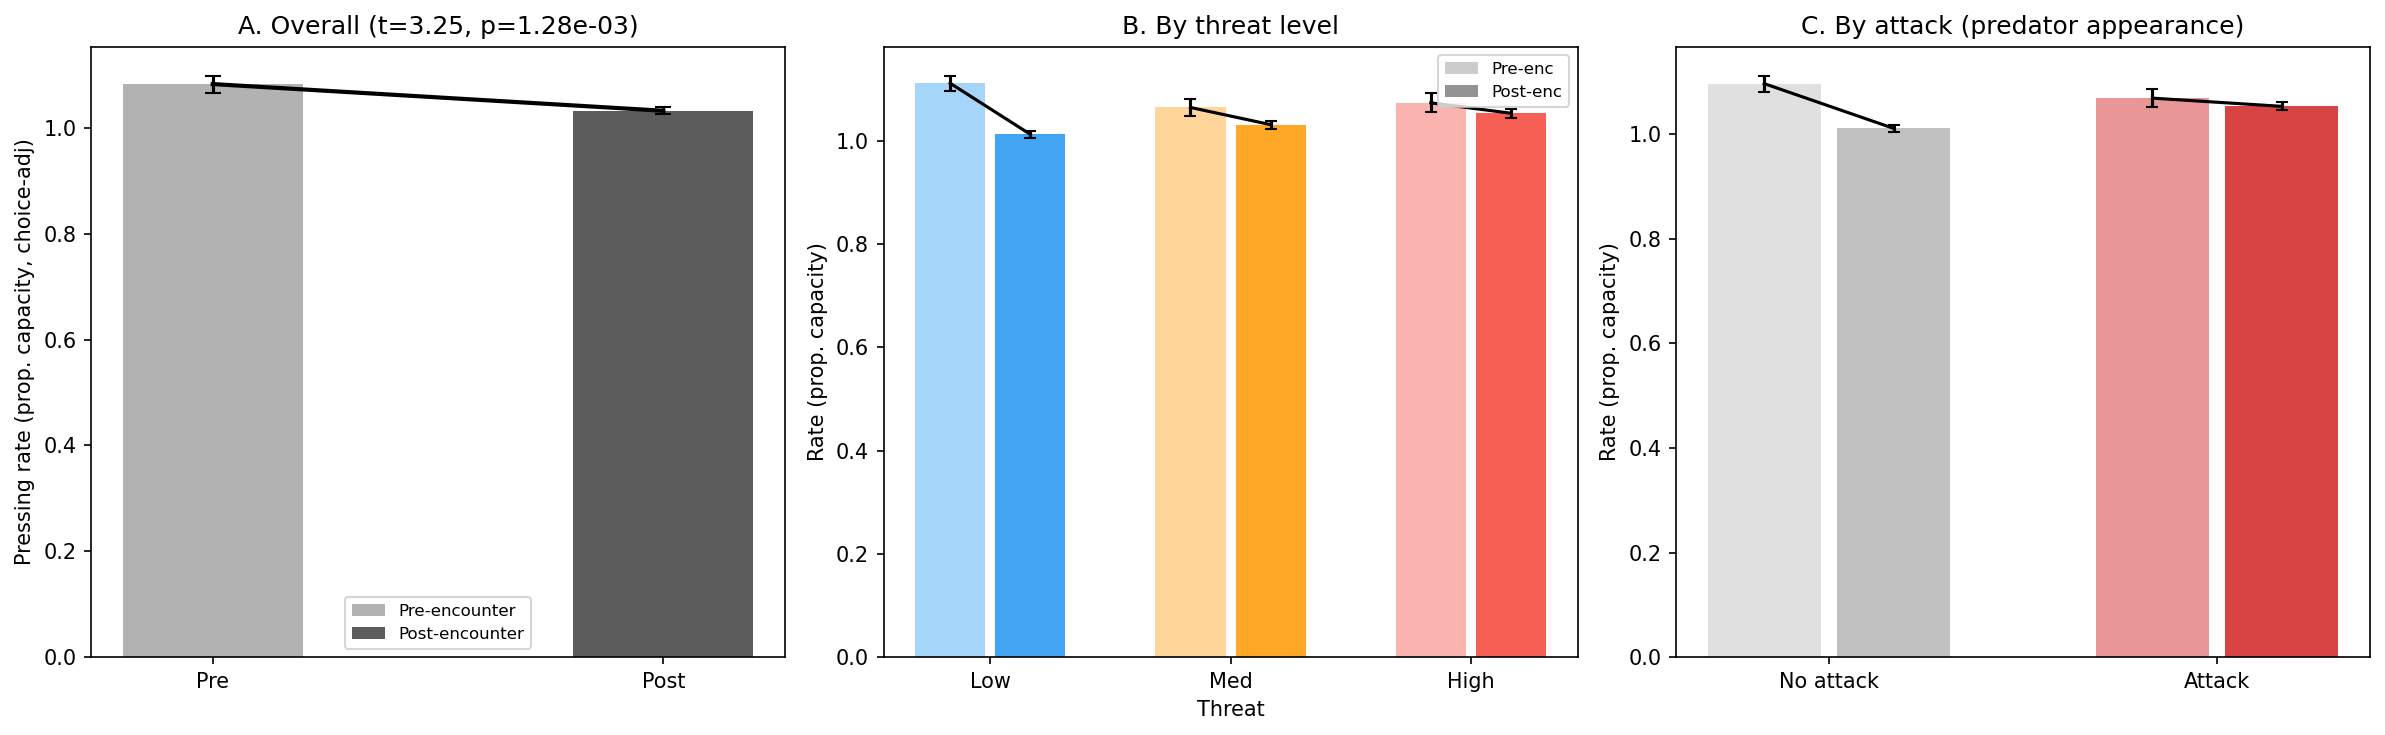

── Stats ──
Overall pre→post: t=3.25, p=1.28e-03
  Threat=0.1: t=6.87, p=3.90e-11
  Threat=0.5: t=1.97, p=4.97e-02
  Threat=0.9: t=1.16, p=2.45e-01


In [3]:
# ── FIG 1: PRE vs POST — Overall + by Threat + by Attack ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=DPI)

# Helper: paired pre/post bar plot with connecting lines
def plot_pre_post(ax, data, group_col, group_vals, colors, labels, title):
    """Plot pre/post means per group with error bars."""
    x_offsets = np.arange(len(group_vals))
    width = 0.3
    
    for i, (gval, color, label) in enumerate(zip(group_vals, colors, labels)):
        sub = data[data[group_col] == gval] if group_col else data
        pre_subj = sub.groupby('subj')['pre_rate_adj'].mean()
        post_subj = sub.groupby('subj')['post_rate_adj'].mean()
        
        ax.bar(i - width/2, pre_subj.mean(), width, color=color, alpha=0.4,
               yerr=pre_subj.sem(), capsize=3, label=f'{label} Pre' if i == 0 else '')
        ax.bar(i + width/2, post_subj.mean(), width, color=color, alpha=0.8,
               yerr=post_subj.sem(), capsize=3, label=f'{label} Post' if i == 0 else '')
        
        # Connect pre→post with line
        ax.plot([i - width/2, i + width/2], [pre_subj.mean(), post_subj.mean()],
                'k-', linewidth=1.5, alpha=0.5)
    
    ax.set_xticks(x_offsets)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Pressing rate (prop. capacity, choice-adj)')
    ax.set_title(title)

# Panel A: Overall
ax = axes[0]
pre_subj = pc.groupby('subj')['pre_rate_adj'].mean()
post_subj = pc.groupby('subj')['post_rate_adj'].mean()
ax.bar(0, pre_subj.mean(), 0.4, color='#666', alpha=0.5, yerr=pre_subj.sem(), capsize=4, label='Pre-encounter')
ax.bar(1, post_subj.mean(), 0.4, color='#333', alpha=0.8, yerr=post_subj.sem(), capsize=4, label='Post-encounter')
ax.plot([0, 1], [pre_subj.mean(), post_subj.mean()], 'k-', linewidth=2)
t_overall, p_overall = stats.ttest_rel(pre_subj, post_subj)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Pre', 'Post'])
ax.set_ylabel('Pressing rate (prop. capacity, choice-adj)')
ax.set_title(f'A. Overall (t={t_overall:.2f}, p={p_overall:.2e})')
ax.legend(fontsize=8)

# Panel B: By threat
ax = axes[1]
for i, th in enumerate([0.1, 0.5, 0.9]):
    sub = pc[pc['threat'] == th]
    pre_s = sub.groupby('subj')['pre_rate_adj'].mean()
    post_s = sub.groupby('subj')['post_rate_adj'].mean()
    x = i * 1.2
    ax.bar(x, pre_s.mean(), 0.35, color=THREAT_COLORS[th], alpha=0.4,
           yerr=pre_s.sem(), capsize=3)
    ax.bar(x + 0.4, post_s.mean(), 0.35, color=THREAT_COLORS[th], alpha=0.85,
           yerr=post_s.sem(), capsize=3)
    ax.plot([x, x + 0.4], [pre_s.mean(), post_s.mean()], 'k-', linewidth=1.5)
    
ax.set_xticks([i * 1.2 + 0.2 for i in range(3)])
ax.set_xticklabels(['Low', 'Med', 'High'])
ax.set_xlabel('Threat')
ax.set_ylabel('Rate (prop. capacity)')
ax.set_title('B. By threat level')
# Add legend manually
from matplotlib.patches import Patch
ax.legend([Patch(alpha=0.4, fc='gray'), Patch(alpha=0.85, fc='gray')],
          ['Pre-enc', 'Post-enc'], fontsize=8)

# Panel C: By attack (within-threat averaged)
ax = axes[2]
for i, (atk_val, atk_label, alpha_pre, alpha_post) in enumerate([
    (0, 'No attack', 0.3, 0.6), (1, 'Attack', 0.5, 0.9)
]):
    sub = pc[pc['attack'] == atk_val]
    pre_s = sub.groupby('subj')['pre_rate_adj'].mean()
    post_s = sub.groupby('subj')['post_rate_adj'].mean()
    color = '#999' if atk_val == 0 else '#D32F2F'
    x = i * 1.2
    ax.bar(x, pre_s.mean(), 0.35, color=color, alpha=alpha_pre,
           yerr=pre_s.sem(), capsize=3)
    ax.bar(x + 0.4, post_s.mean(), 0.35, color=color, alpha=alpha_post,
           yerr=post_s.sem(), capsize=3)
    ax.plot([x, x + 0.4], [pre_s.mean(), post_s.mean()], 'k-', linewidth=1.5)

ax.set_xticks([i * 1.2 + 0.2 for i in range(2)])
ax.set_xticklabels(['No attack', 'Attack'])
ax.set_ylabel('Rate (prop. capacity)')
ax.set_title('C. By attack (predator appearance)')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig_encounter_pre_post_overview.png', dpi=300, bbox_inches='tight')
plt.show()

# Print stats
print('── Stats ──')
print(f'Overall pre→post: t={t_overall:.2f}, p={p_overall:.2e}')
for th in [0.1, 0.5, 0.9]:
    sub = pc[pc['threat'] == th]
    t_th, p_th = stats.ttest_rel(sub.groupby('subj')['pre_rate_adj'].mean(),
                                  sub.groupby('subj')['post_rate_adj'].mean())
    print(f'  Threat={th}: t={t_th:.2f}, p={p_th:.2e}')

## Parameter tertile splits
For each parameter (z, k, β), split subjects into Low/Mid/High tertiles and visualize how the pre/post encounter pattern differs. Key question: does the encounter transition shape change as a function of the choice model parameters?

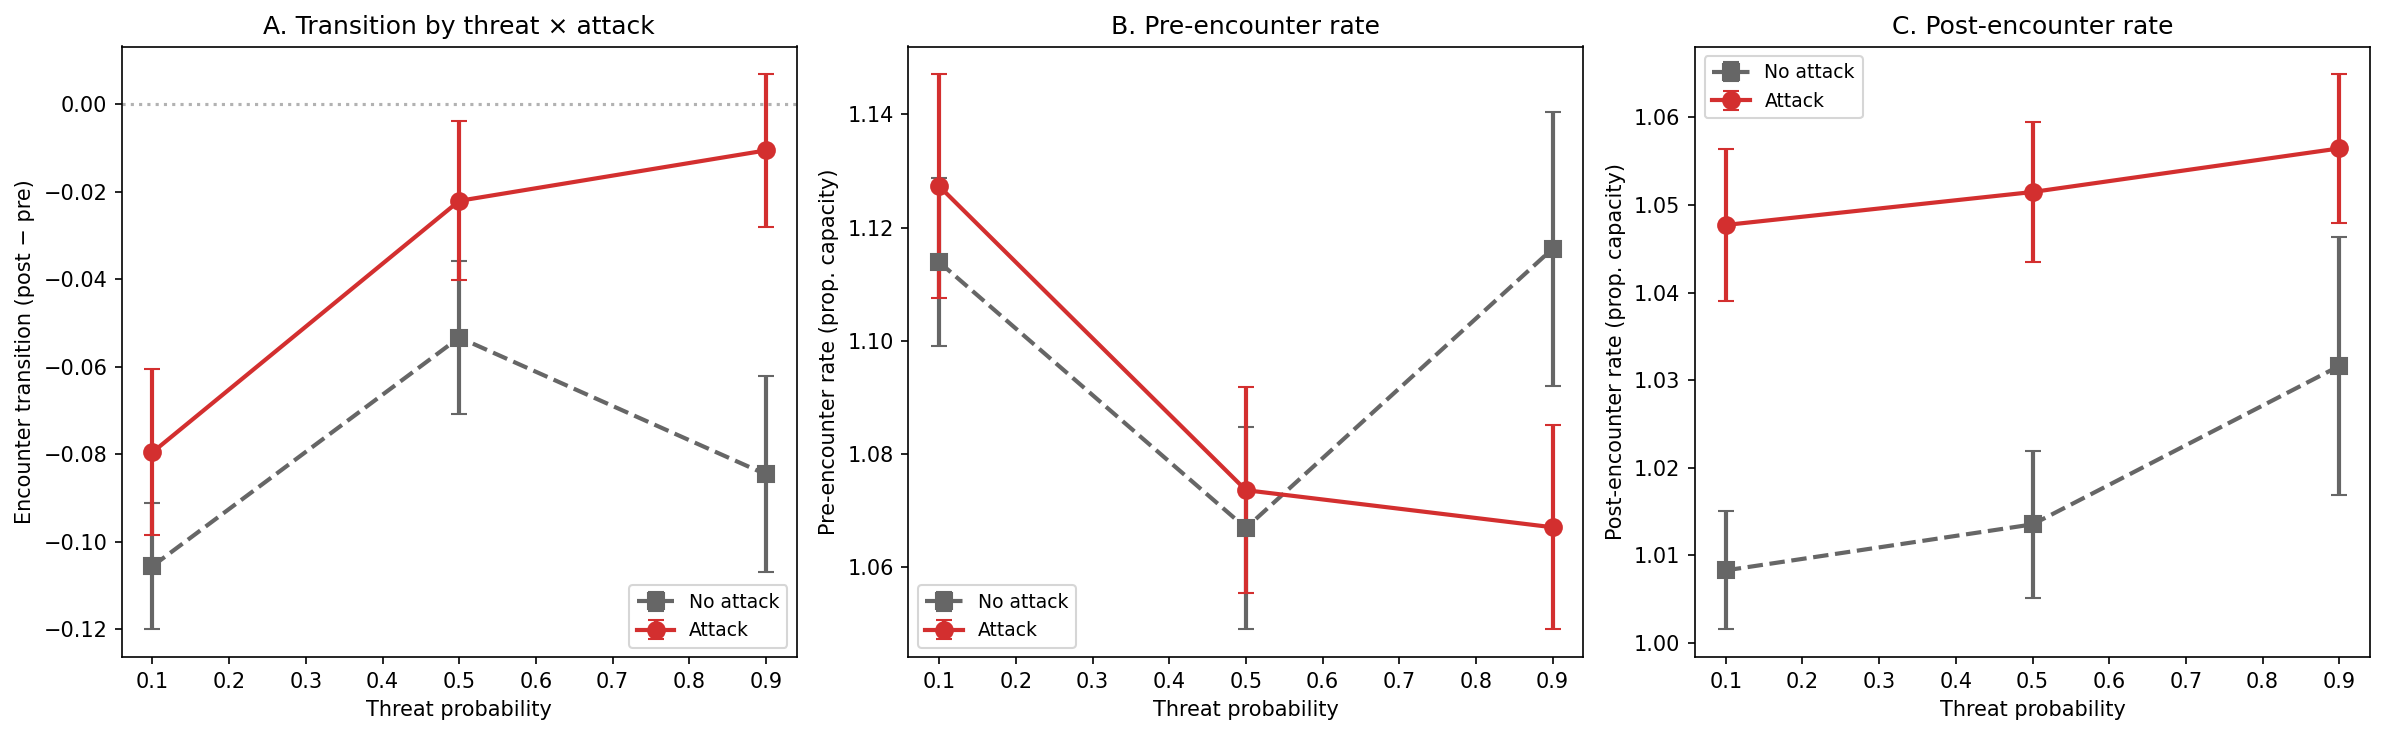

In [4]:
# ── FIG 2: THREAT × ATTACK interaction on encounter transition ────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=DPI)

# Panel A: Transition by threat × attack
ax = axes[0]
for atk_val, ls, marker, label in [(0, '--', 's', 'No attack'), (1, '-', 'o', 'Attack')]:
    means, sems = [], []
    for th in [0.1, 0.5, 0.9]:
        sub = pc[(pc['threat'] == th) & (pc['attack'] == atk_val)]
        subj_m = sub.groupby('subj')['transition'].mean()
        means.append(subj_m.mean())
        sems.append(subj_m.sem())
    color = '#D32F2F' if atk_val else '#666'
    ax.errorbar([0.1, 0.5, 0.9], means, yerr=sems, fmt=f'{marker}{ls}',
                color=color, linewidth=2, markersize=8, capsize=4, label=label)

ax.axhline(0, color='k', linestyle=':', alpha=0.3)
ax.set_xlabel('Threat probability')
ax.set_ylabel('Encounter transition (post − pre)')
ax.set_title('A. Transition by threat × attack')
ax.legend(fontsize=9)

# Panel B: Pre-encounter rate by threat × attack
ax = axes[1]
for atk_val, ls, marker, label in [(0, '--', 's', 'No attack'), (1, '-', 'o', 'Attack')]:
    means, sems = [], []
    for th in [0.1, 0.5, 0.9]:
        sub = pc[(pc['threat'] == th) & (pc['attack'] == atk_val)]
        subj_m = sub.groupby('subj')['pre_rate_adj'].mean()
        means.append(subj_m.mean())
        sems.append(subj_m.sem())
    color = '#D32F2F' if atk_val else '#666'
    ax.errorbar([0.1, 0.5, 0.9], means, yerr=sems, fmt=f'{marker}{ls}',
                color=color, linewidth=2, markersize=8, capsize=4, label=label)

ax.set_xlabel('Threat probability')
ax.set_ylabel('Pre-encounter rate (prop. capacity)')
ax.set_title('B. Pre-encounter rate')
ax.legend(fontsize=9)

# Panel C: Post-encounter rate by threat × attack
ax = axes[2]
for atk_val, ls, marker, label in [(0, '--', 's', 'No attack'), (1, '-', 'o', 'Attack')]:
    means, sems = [], []
    for th in [0.1, 0.5, 0.9]:
        sub = pc[(pc['threat'] == th) & (pc['attack'] == atk_val)]
        subj_m = sub.groupby('subj')['post_rate_adj'].mean()
        means.append(subj_m.mean())
        sems.append(subj_m.sem())
    color = '#D32F2F' if atk_val else '#666'
    ax.errorbar([0.1, 0.5, 0.9], means, yerr=sems, fmt=f'{marker}{ls}',
                color=color, linewidth=2, markersize=8, capsize=4, label=label)

ax.set_xlabel('Threat probability')
ax.set_ylabel('Post-encounter rate (prop. capacity)')
ax.set_title('C. Post-encounter rate')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig_encounter_threat_attack.png', dpi=300, bbox_inches='tight')
plt.show()

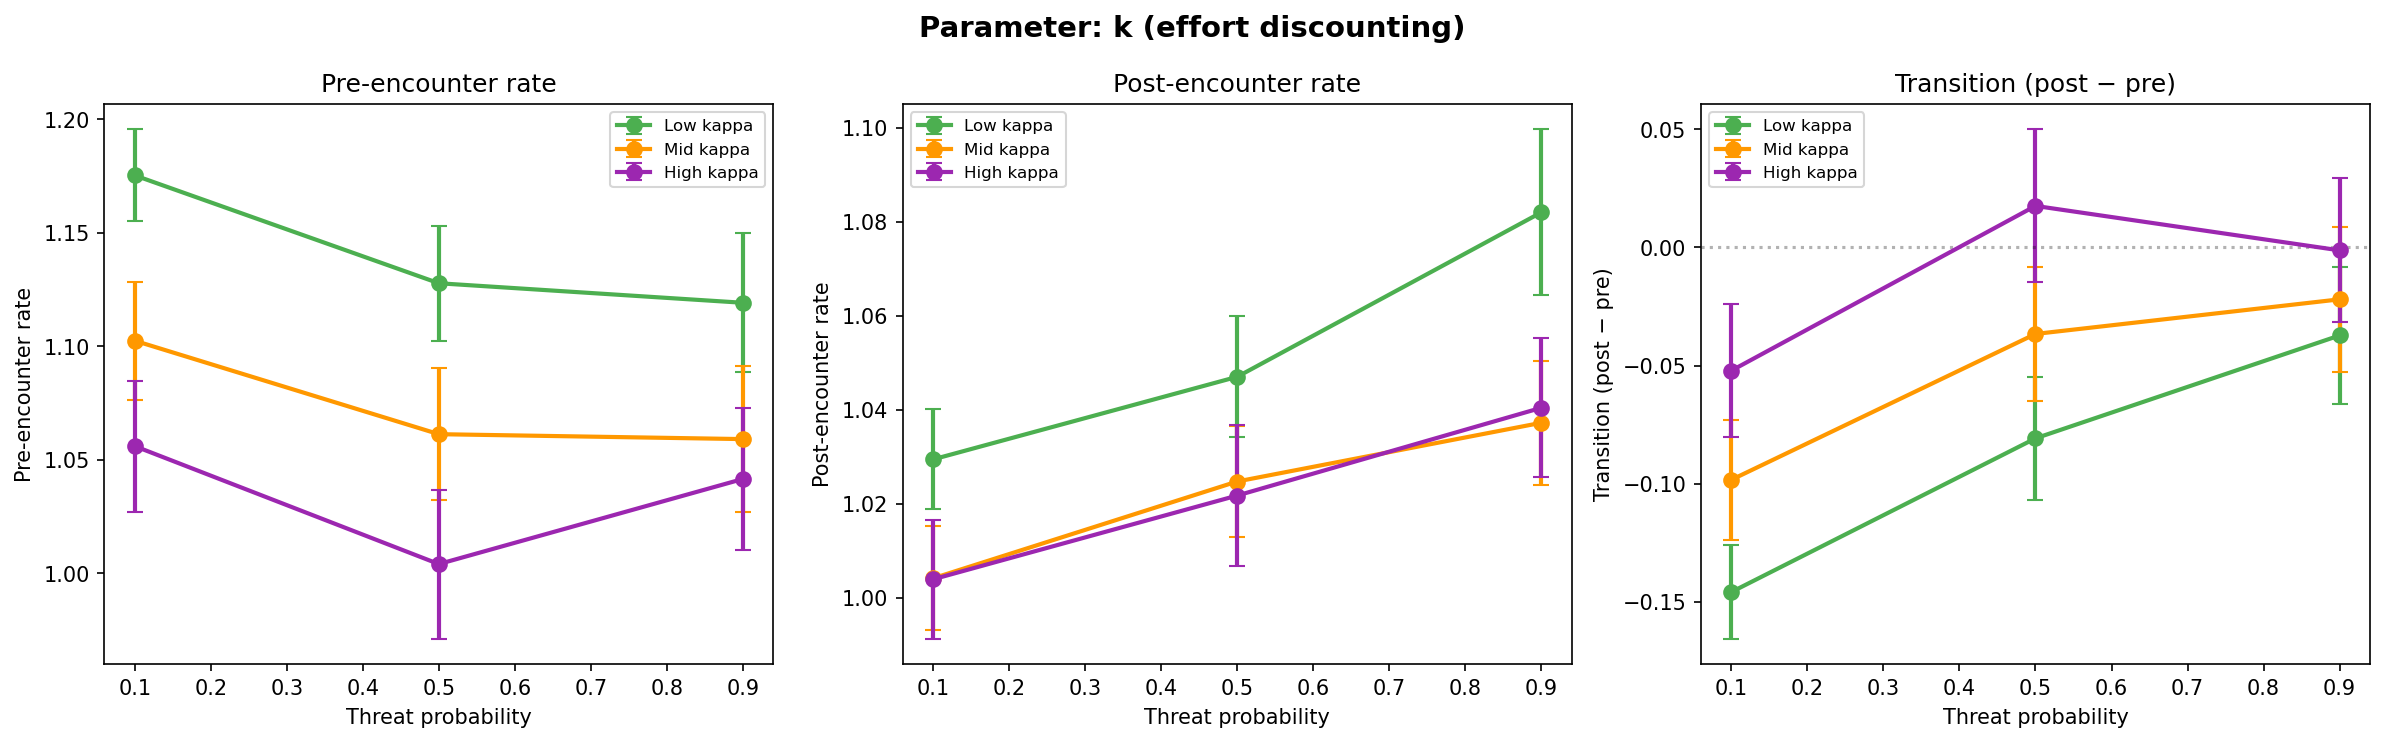


── k (effort discounting) tertile means ──
   Low (N=98): pre=1.141, post=1.052, trans=-0.088
   Mid (N=97): pre=1.074, post=1.022, trans=-0.052
  High (N=98): pre=1.034, post=1.023, trans=-0.011


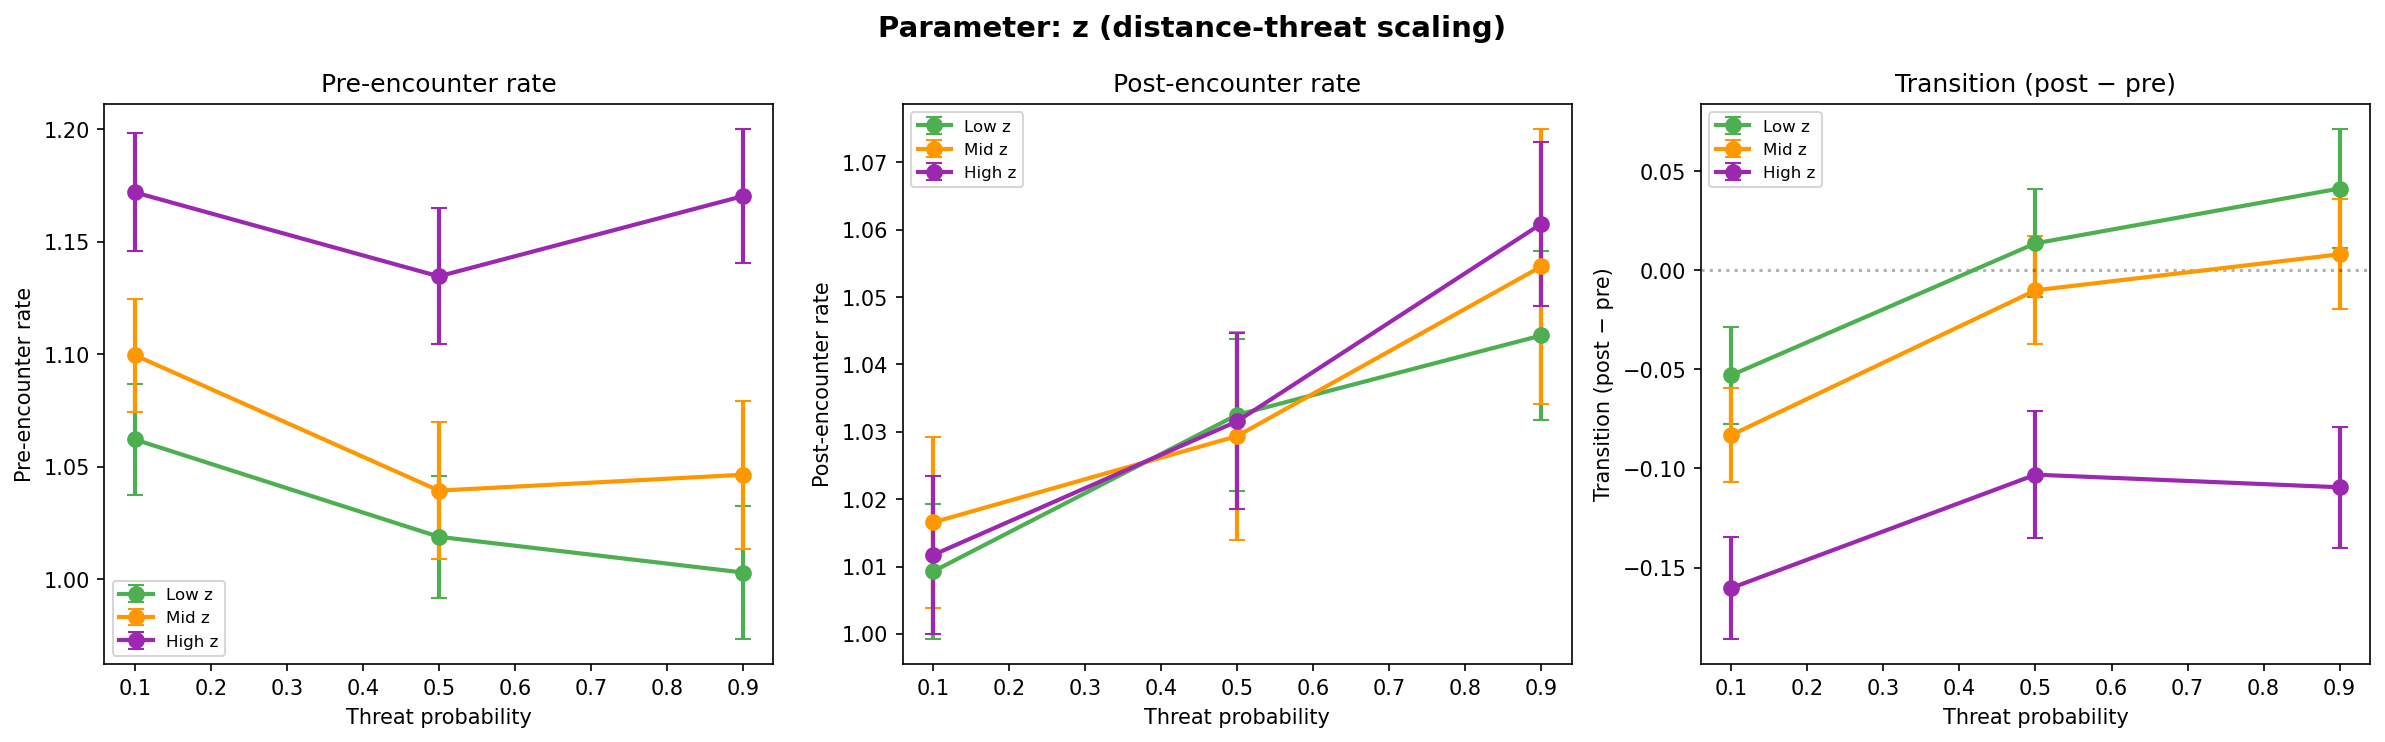


── z (distance-threat scaling) tertile means ──
   Low (N=98): pre=1.028, post=1.029, trans=+0.001
   Mid (N=97): pre=1.062, post=1.034, trans=-0.028
  High (N=98): pre=1.159, post=1.035, trans=-0.124


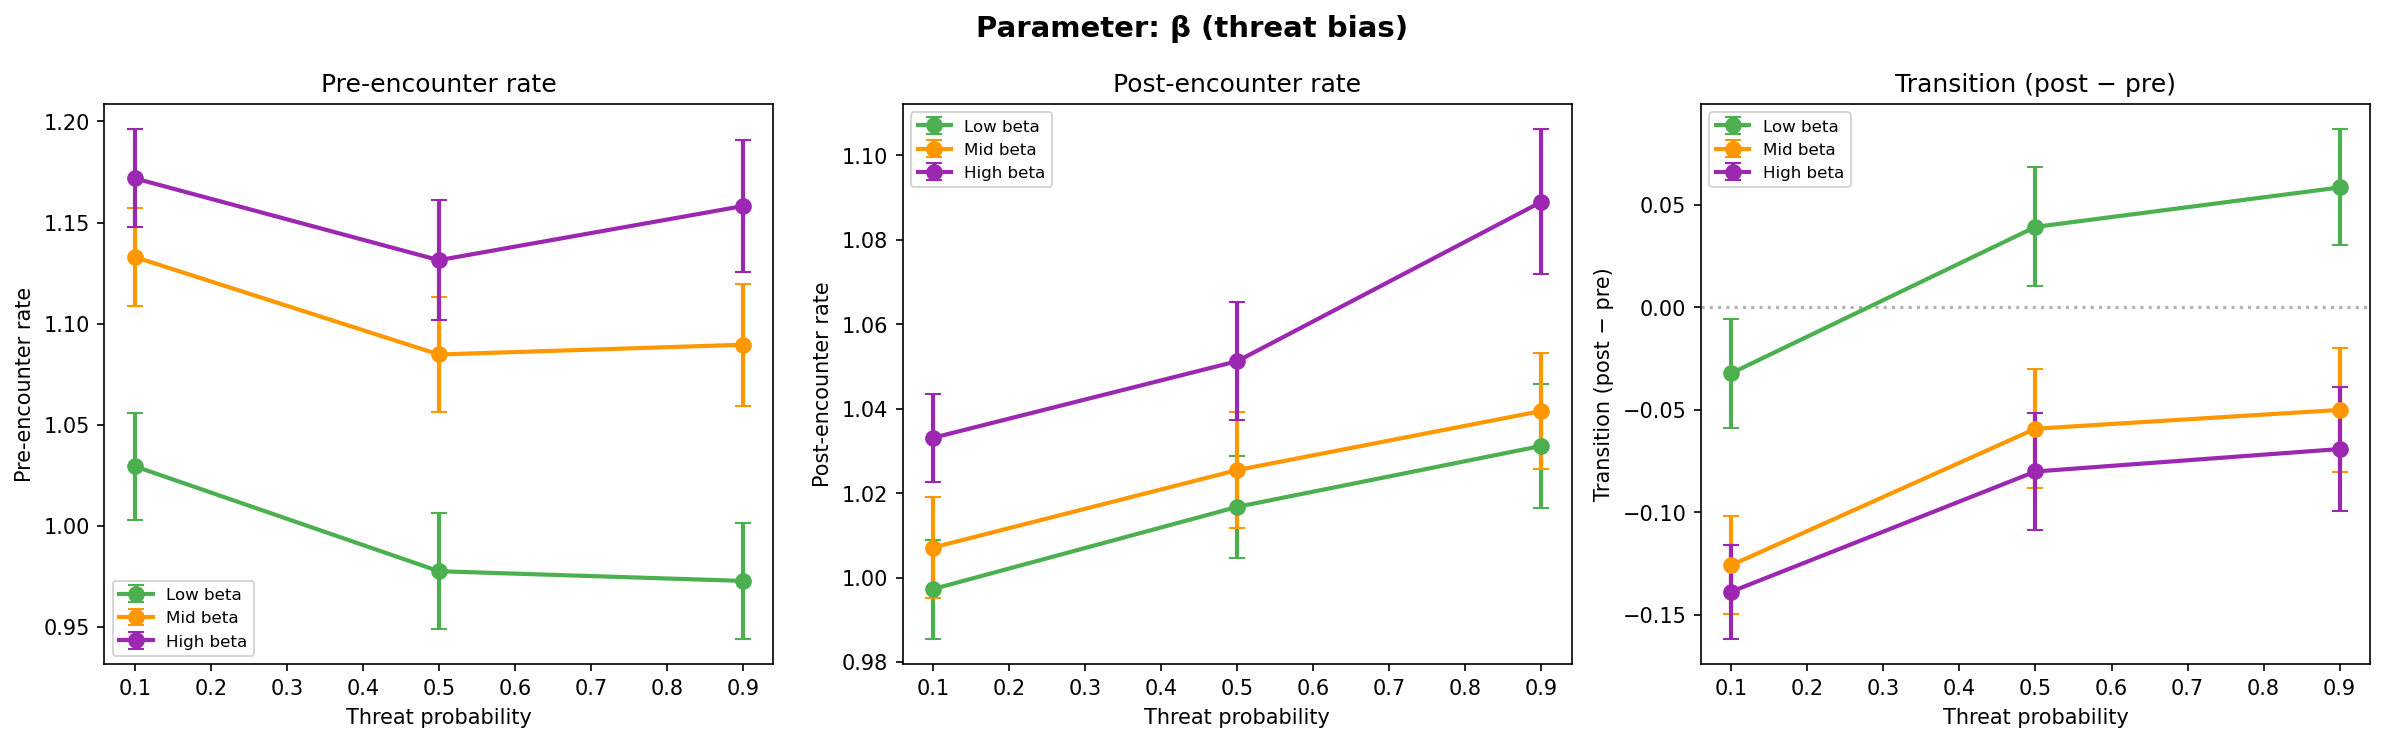


── β (threat bias) tertile means ──
   Low (N=98): pre=0.993, post=1.016, trans=+0.023
   Mid (N=97): pre=1.103, post=1.024, trans=-0.079
  High (N=98): pre=1.153, post=1.058, trans=-0.096


In [5]:
# ── FIG 3: PARAMETER TERTILE SPLITS — Pre/Post by threat ─────────────────────
# For each param, show pre/post × threat for Low/Mid/High tertile groups

TERT_COLORS = {'Low': '#4CAF50', 'Mid': '#FF9800', 'High': '#9C27B0'}

for param, param_label in [('kappa', 'k (effort discounting)'), 
                             ('z', 'z (distance-threat scaling)'),
                             ('beta', 'β (threat bias)')]:
    tert_col = f'{param}_tert'
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=DPI)
    fig.suptitle(f'Parameter: {param_label}', fontsize=14, fontweight='bold')
    
    for col_idx, (dv, dv_label) in enumerate([
        ('pre_rate_adj', 'Pre-encounter rate'),
        ('post_rate_adj', 'Post-encounter rate'),
        ('transition', 'Transition (post − pre)'),
    ]):
        ax = axes[col_idx]
        
        for tert in ['Low', 'Mid', 'High']:
            subjs = param_df[param_df[tert_col] == tert].index
            sub = pc[pc['subj'].isin(subjs)]
            
            means, sems = [], []
            for th in [0.1, 0.5, 0.9]:
                s = sub[sub['threat'] == th]
                subj_m = s.groupby('subj')[dv].mean()
                means.append(subj_m.mean())
                sems.append(subj_m.sem())
            
            ax.errorbar([0.1, 0.5, 0.9], means, yerr=sems, fmt='o-',
                        color=TERT_COLORS[tert], linewidth=2, markersize=7,
                        capsize=4, label=f'{tert} {param}')
        
        if dv == 'transition':
            ax.axhline(0, color='k', linestyle=':', alpha=0.3)
        
        ax.set_xlabel('Threat probability')
        ax.set_ylabel(dv_label)
        ax.set_title(dv_label)
        ax.legend(fontsize=8)
    
    plt.tight_layout()
    plt.savefig(FIGS_DIR / f'fig_encounter_tertile_{param}.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print the tertile means
    print(f'\n── {param_label} tertile means ──')
    for tert in ['Low', 'Mid', 'High']:
        subjs = param_df[param_df[tert_col] == tert].index
        sub = pc[pc['subj'].isin(subjs)]
        pre_m = sub.groupby('subj')['pre_rate_adj'].mean().mean()
        post_m = sub.groupby('subj')['post_rate_adj'].mean().mean()
        trans_m = sub.groupby('subj')['transition'].mean().mean()
        n = sub['subj'].nunique()
        print(f'  {tert:>4s} (N={n}): pre={pre_m:.3f}, post={post_m:.3f}, trans={trans_m:+.3f}')

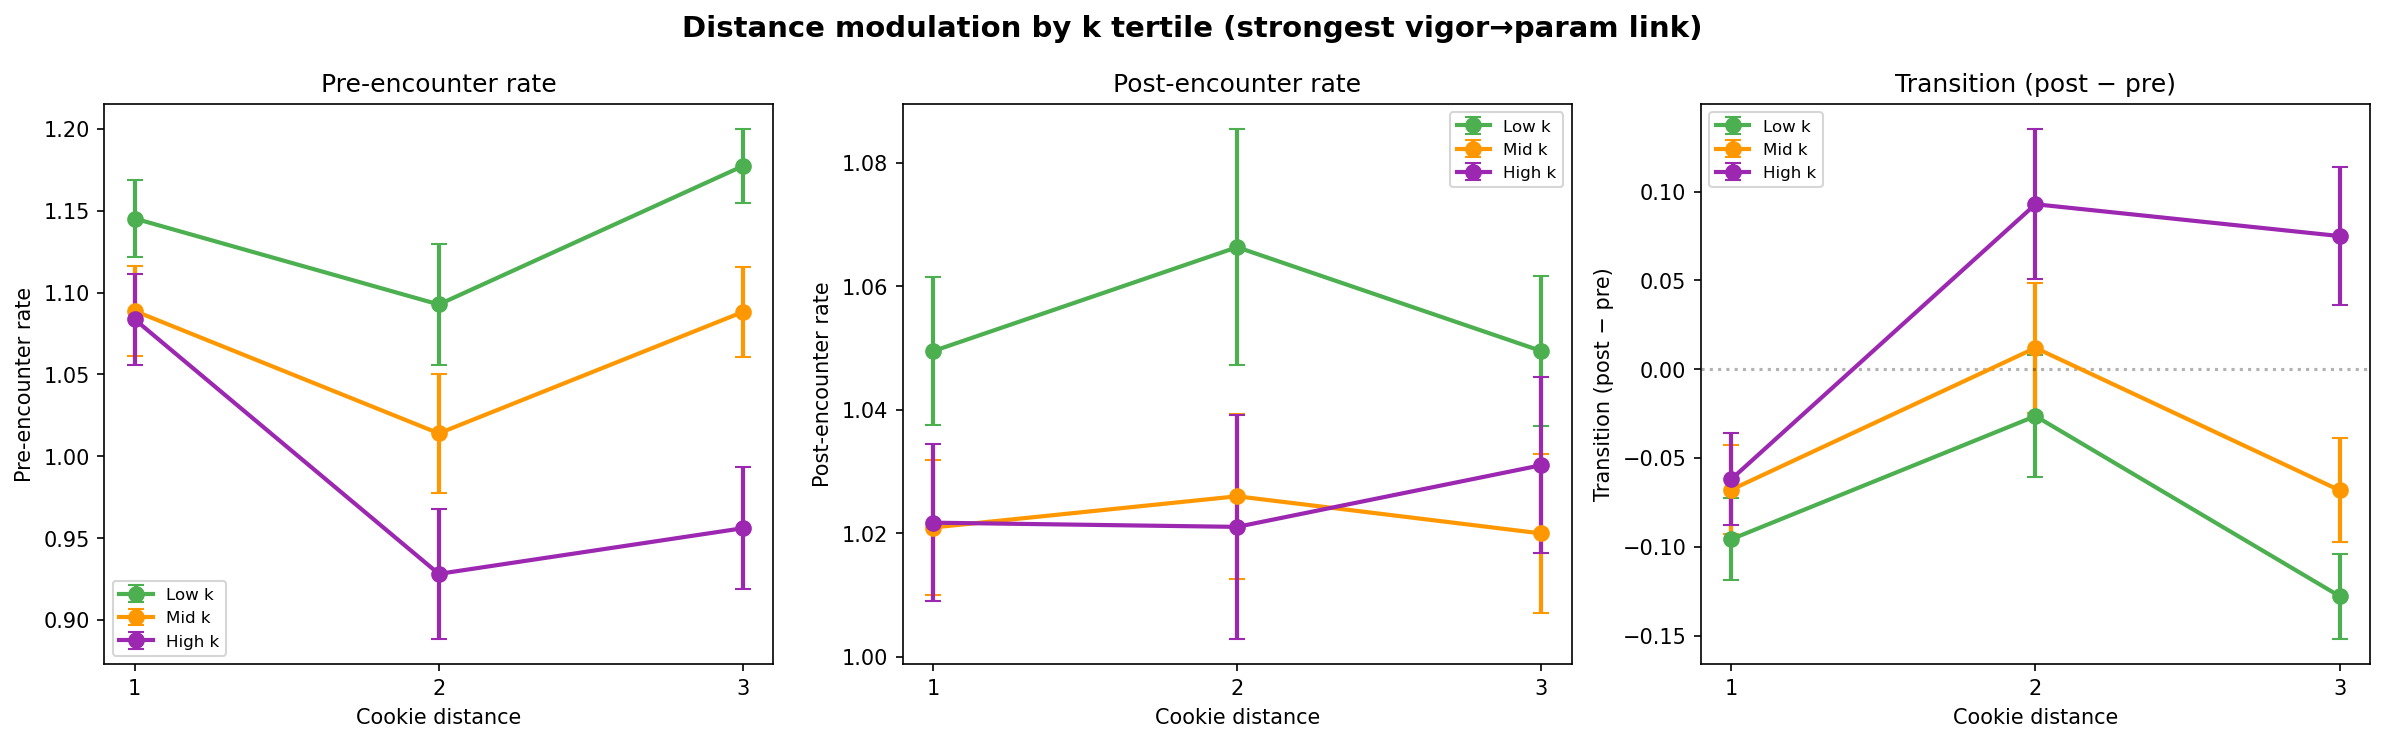

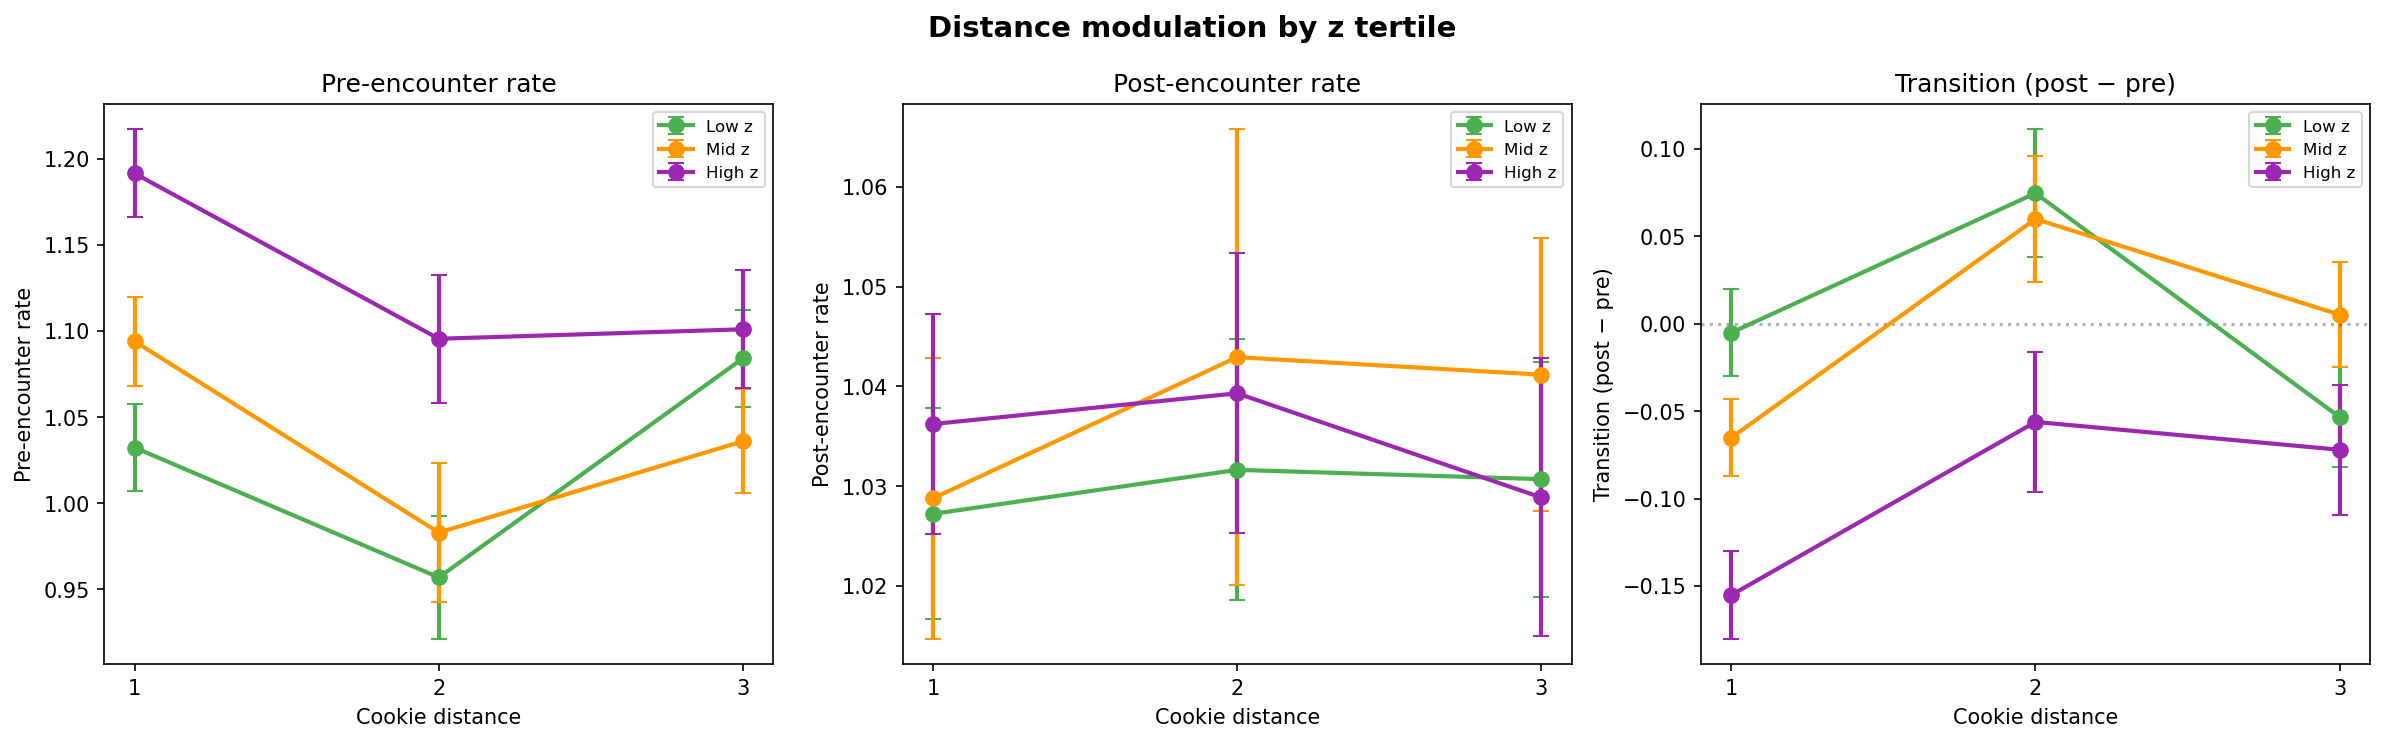

In [6]:
# ── FIG 4: DISTANCE × PARAMETER TERTILE (the key individual-diff finding) ─────
# dist_pre × k was r=-0.435. Visualize: how does pressing rate vary with distance
# in the pre-encounter window, split by k tertile?

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=DPI)
fig.suptitle('Distance modulation by k tertile (strongest vigor→param link)', 
             fontsize=14, fontweight='bold')

for col_idx, (dv, dv_label) in enumerate([
    ('pre_rate_adj', 'Pre-encounter rate'),
    ('post_rate_adj', 'Post-encounter rate'),
    ('transition', 'Transition (post − pre)'),
]):
    ax = axes[col_idx]
    
    for tert in ['Low', 'Mid', 'High']:
        subjs = param_df[param_df['kappa_tert'] == tert].index
        sub = pc[pc['subj'].isin(subjs)]
        
        means, sems = [], []
        for d in [1, 2, 3]:
            s = sub[sub['distance_H'] == d]
            subj_m = s.groupby('subj')[dv].mean()
            means.append(subj_m.mean())
            sems.append(subj_m.sem())
        
        ax.errorbar([1, 2, 3], means, yerr=sems, fmt='o-',
                    color=TERT_COLORS[tert], linewidth=2, markersize=7,
                    capsize=4, label=f'{tert} k')
    
    if dv == 'transition':
        ax.axhline(0, color='k', linestyle=':', alpha=0.3)
    
    ax.set_xlabel('Cookie distance')
    ax.set_ylabel(dv_label)
    ax.set_title(dv_label)
    ax.set_xticks([1, 2, 3])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig_encounter_dist_k_tertile.png', dpi=300, bbox_inches='tight')
plt.show()

# Same for z
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=DPI)
fig.suptitle('Distance modulation by z tertile', fontsize=14, fontweight='bold')

for col_idx, (dv, dv_label) in enumerate([
    ('pre_rate_adj', 'Pre-encounter rate'),
    ('post_rate_adj', 'Post-encounter rate'),
    ('transition', 'Transition (post − pre)'),
]):
    ax = axes[col_idx]
    
    for tert in ['Low', 'Mid', 'High']:
        subjs = param_df[param_df['z_tert'] == tert].index
        sub = pc[pc['subj'].isin(subjs)]
        
        means, sems = [], []
        for d in [1, 2, 3]:
            s = sub[sub['distance_H'] == d]
            subj_m = s.groupby('subj')[dv].mean()
            means.append(subj_m.mean())
            sems.append(subj_m.sem())
        
        ax.errorbar([1, 2, 3], means, yerr=sems, fmt='o-',
                    color=TERT_COLORS[tert], linewidth=2, markersize=7,
                    capsize=4, label=f'{tert} z')
    
    if dv == 'transition':
        ax.axhline(0, color='k', linestyle=':', alpha=0.3)
    
    ax.set_xlabel('Cookie distance')
    ax.set_ylabel(dv_label)
    ax.set_title(dv_label)
    ax.set_xticks([1, 2, 3])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig_encounter_dist_z_tertile.png', dpi=300, bbox_inches='tight')
plt.show()

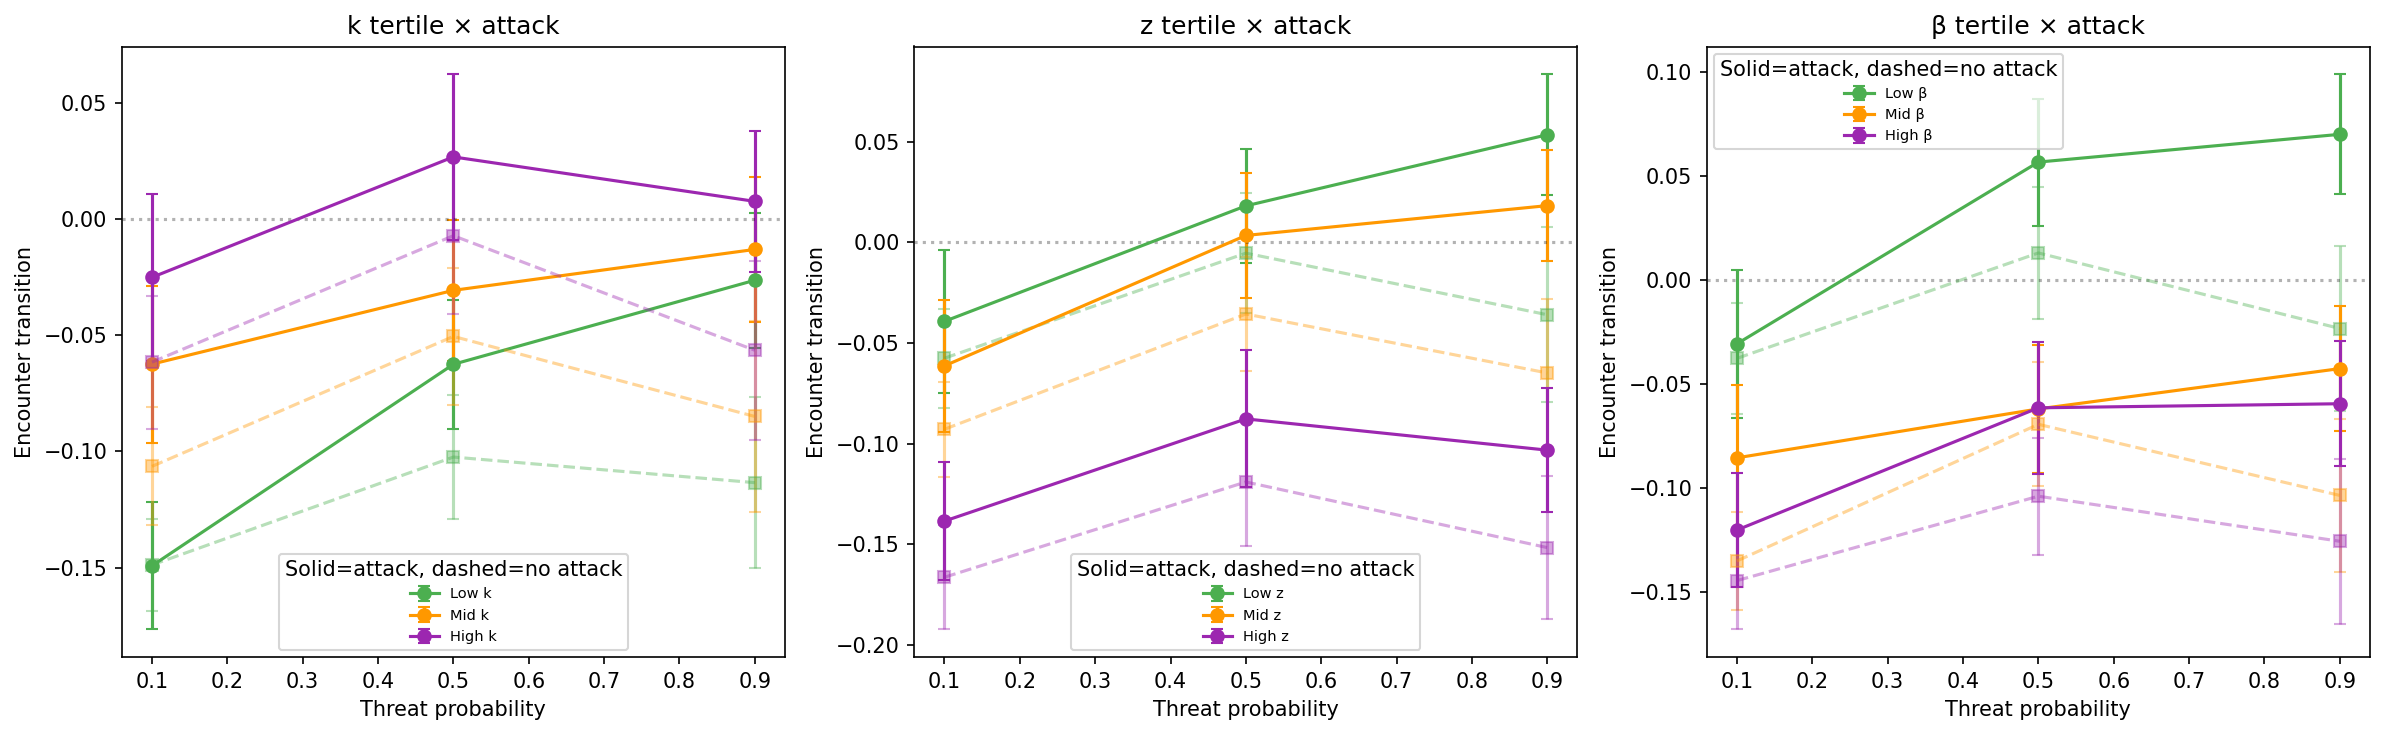

In [7]:
# ── FIG 5: ATTACK EFFECT split by param tertile ──────────────────────────────
# Does the attack-driven encounter boost differ by parameter group?

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=DPI)

for col_idx, (param, param_label) in enumerate([
    ('kappa', 'k'), ('z', 'z'), ('beta', 'β')
]):
    ax = axes[col_idx]
    tert_col = f'{param}_tert'
    
    for tert in ['Low', 'Mid', 'High']:
        subjs = param_df[param_df[tert_col] == tert].index
        sub = pc[pc['subj'].isin(subjs)]
        
        # Attack vs no-attack transition per threat level
        for atk_val, ls, marker in [(0, '--', 's'), (1, '-', 'o')]:
            means, sems = [], []
            for th in [0.1, 0.5, 0.9]:
                s = sub[(sub['threat'] == th) & (sub['attack'] == atk_val)]
                subj_m = s.groupby('subj')['transition'].mean()
                means.append(subj_m.mean())
                sems.append(subj_m.sem())
            
            alpha = 0.4 if atk_val == 0 else 1.0
            label = f'{tert} {param_label}' if atk_val == 1 else None
            ax.errorbar([0.1, 0.5, 0.9], means, yerr=sems, 
                        fmt=f'{marker}{ls}', color=TERT_COLORS[tert],
                        linewidth=1.5, markersize=6, capsize=3,
                        alpha=alpha, label=label)
    
    ax.axhline(0, color='k', linestyle=':', alpha=0.3)
    ax.set_xlabel('Threat probability')
    ax.set_ylabel('Encounter transition')
    ax.set_title(f'{param_label} tertile × attack')
    ax.legend(fontsize=7, title='Solid=attack, dashed=no attack')

plt.tight_layout()
plt.savefig(FIGS_DIR / 'fig_encounter_attack_param_tertile.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
# ── FIG 6: SUMMARY STATS TABLE ───────────────────────────────────────────────

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold

# Bivariate correlations for encounter-window features
features = {}
for col, label in [('pre_rate_adj','pre'), ('post_rate_adj','post'), ('transition','trans')]:
    features[f'tonic_{label}'] = pc.groupby('subj')[col].mean()
    
    threat_s, dist_s, attack_s = [], [], []
    for subj, grp in pc.groupby('subj'):
        df = grp[[col,'threat','distance_H','isAttackTrial']].dropna()
        if len(df) < 10:
            threat_s.append((subj, np.nan)); dist_s.append((subj, np.nan)); attack_s.append((subj, np.nan))
            continue
        Xt = (df['threat'] - df['threat'].mean()) / max(df['threat'].std(), 1e-10)
        Xd = (df['distance_H'] - df['distance_H'].mean()) / max(df['distance_H'].std(), 1e-10)
        Xa = (df['isAttackTrial'].astype(float) - df['isAttackTrial'].mean()) / max(df['isAttackTrial'].astype(float).std(), 1e-10)
        X = np.column_stack([Xt, Xd, Xa])
        y = df[col].values
        reg = LinearRegression().fit(X, y)
        threat_s.append((subj, reg.coef_[0]))
        dist_s.append((subj, reg.coef_[1]))
        attack_s.append((subj, reg.coef_[2]))
    
    features[f'threat_{label}'] = pd.DataFrame(threat_s, columns=['subj','v']).set_index('subj')['v']
    features[f'dist_{label}'] = pd.DataFrame(dist_s, columns=['subj','v']).set_index('subj')['v']
    features[f'attack_{label}'] = pd.DataFrame(attack_s, columns=['subj','v']).set_index('subj')['v']

feat_df = pd.DataFrame(features)
merged = feat_df.join(param_df[['z','kappa','beta']]).dropna()

print('══════════════════════════════════════════════════════════════════════')
print('FEATURE × PARAMETER CORRELATIONS')
print('══════════════════════════════════════════════════════════════════════')
print(f'\n  {"Feature":<25s} {"z":>10s} {"k":>10s} {"β":>10s}')
print('  ' + '-'*57)

for feat in feat_df.columns:
    row = f'  {feat:<25s}'
    for param in ['z','kappa','beta']:
        x = merged[feat].values
        y = merged[param].values
        x_z = (x - x.mean()) / x.std()
        y_z = (y - y.mean()) / y.std()
        r, p = stats.pearsonr(x_z, y_z)
        sig = '**' if p < 0.01 else '*' if p < 0.05 else ''
        row += f'  {r:>+.3f}{sig:<2s}'
    print(row)

# PLS summary
X = merged[feat_df.columns].values
Y = merged[['z','kappa','beta']].values
X_z = (X - X.mean(0)) / X.std(0)
Y_z = (Y - Y.mean(0)) / Y.std(0)

print(f'\n══════════════════════════════════════════════════════════════════════')
print(f'PLS CROSS-VALIDATION (N={len(merged)})')
print(f'══════════════════════════════════════════════════════════════════════')

for nc in [1, 2, 3]:
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2, per_p = [], {p: [] for p in ['z','kappa','beta']}
    for tr, te in kf.split(X_z):
        pls = PLSRegression(n_components=nc).fit(X_z[tr], Y_z[tr])
        Yp = pls.predict(X_z[te])
        cv_r2.append(1 - np.sum((Y_z[te]-Yp)**2) / np.sum((Y_z[te]-Y_z[te].mean(0))**2))
        for j, p in enumerate(['z','kappa','beta']):
            per_p[p].append(1 - np.sum((Y_z[te,j]-Yp[:,j])**2) / np.sum((Y_z[te,j]-Y_z[te,j].mean())**2))
    
    print(f'\n  {nc} comp: CV R²={np.mean(cv_r2):.3f} (±{np.std(cv_r2):.3f})')
    for p in ['z','kappa','beta']:
        print(f'    {p}: CV R²={np.mean(per_p[p]):.3f}')

══════════════════════════════════════════════════════════════════════
FEATURE × PARAMETER CORRELATIONS
══════════════════════════════════════════════════════════════════════

  Feature                            z          k          β
  ---------------------------------------------------------
  tonic_pre                  +0.176**  -0.159**  +0.106  
  threat_pre                 +0.083    +0.075    +0.132* 
  dist_pre                   -0.257**  -0.429**  -0.209**
  attack_pre                 +0.021    +0.040    -0.068  
  tonic_post                 -0.042    -0.130*   +0.107  
  threat_post                -0.031    -0.047    +0.017  
  dist_post                  -0.115    +0.038    +0.088  
  attack_post                +0.085    +0.074    -0.069  
  tonic_trans                -0.202**  +0.105    -0.061  
  threat_trans               -0.117*   -0.121*   -0.135* 
  dist_trans                 +0.192**  +0.405**  +0.223**
  attack_trans               +0.027    +0.000    +0.031  

══════